<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/BREASTCANCER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

data = load_breast_cancer()
X, y = data.data, data.target
print(f"Shape: {X.shape}")



Shape: (569, 30)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
}
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Train time (ms)": train_time * 1000,
    })

results_df = pd.DataFrame(results)
print(results_df.round(3))



           Model  Accuracy  Precision  Recall     F1  Train time (ms)
0  Decision Tree     0.912      0.956   0.903  0.929           32.406
1  Random Forest     0.956      0.959   0.972  0.966          349.758
2      SVM (RBF)     0.982      0.986   0.986  0.986            4.210
3            KNN     0.956      0.959   0.972  0.966            0.635


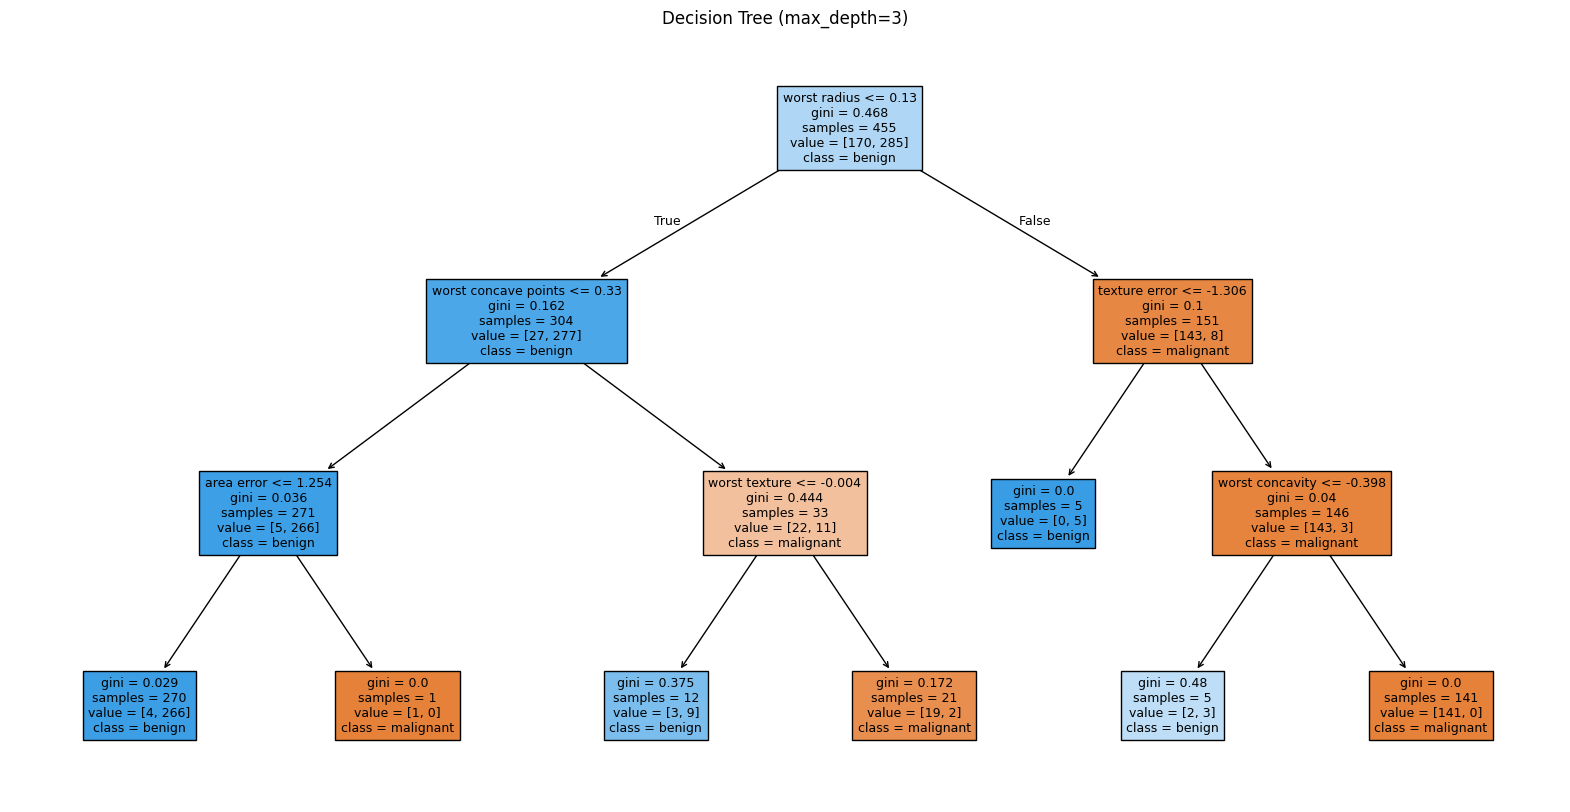

In [6]:
plt.figure(figsize=(20, 10))
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train_scaled, y_train)
plot_tree(small_tree, feature_names=data.feature_names,
          class_names=data.target_names, filled=True, fontsize=9)
plt.title("Decision Tree (max_depth=3)")
plt.show()


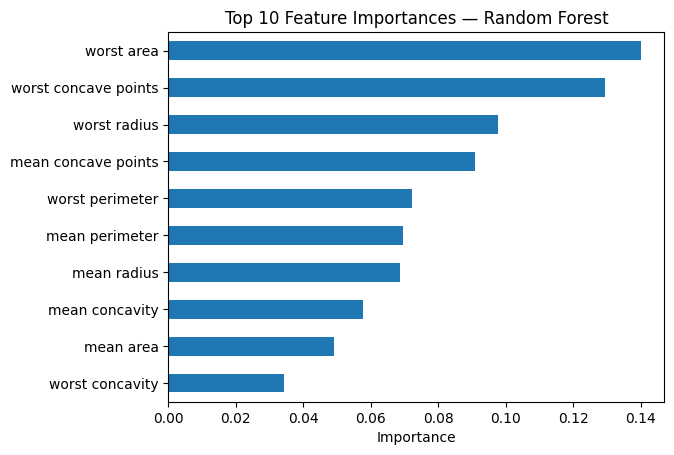

In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=data.feature_names)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


In [8]:
best_model = SVC(random_state=42)
cv_scores = cross_val_score(best_model, scaler.fit_transform(X), y, cv=5)
print(f"Fold scores: {np.round(cv_scores, 3)}")
print(f"Mean: {cv_scores.mean():.3f}   Std: {cv_scores.std():.3f}")



Fold scores: [0.974 0.956 1.    0.965 0.973]
Mean: 0.974   Std: 0.015
